# №3 Згортка, порогові операції, робота з контурами. Ключові точки і матчинг зображень

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def plot_images_in_row(images, titles=None, figsize=(15, 5)):
    number_images = len(images)
    fig, axes = plt.subplots(1, number_images, figsize=figsize)

    if number_images == 1:
        axes = [axes]

    for i in range(number_images):
        axes[i].imshow(images[i])

        if titles is not None and i < len(titles):
            axes[i].set_title(titles[i])

        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

## 2D згортка

#### TODO №1
Реалізувати згортку розміром 5*5 для зображення за шляхом "input/butterflies.jpg"

In [ ]:
# Зчитайте картинку у сірому форматі та відобразіть
img =
plt.imshow(img, cmap="gray")

In [ ]:
# Визначте ядро згортки
kernel =

In [ ]:
# Реалізуйте необхідну логіку


## Фільтрування зображення

### Оператор Собеля

In [ ]:
zebra_img = cv2.imread("input/zebra.png", cv2.IMREAD_COLOR_RGB)
plt.imshow(zebra_img)

In [ ]:
# Виявляє вертикальні контури
kernel_gx = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)

horizontal_edges = cv2.filter2D(zebra_img, -1, kernel_gx)

plt.imshow(horizontal_edges)

#### TODO №2
Напишіть ядро згортки для виявлення горизонтальних меж

In [ ]:
# Ядро для вертикальних меж
kernel_gy =

vertical_edges =


In [ ]:
grad_x = cv2.filter2D(zebra_img, cv2.CV_64F, kernel_gx)
grad_y = cv2.filter2D(zebra_img, cv2.CV_64F, kernel_gy)

# sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
# sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Обчислюємо величину градієнта (Magnitude)
# Формула: sqrt(grad_x^2 + grad_y^2)
magnitude = cv2.magnitude(grad_x, grad_y)

# Перетворюємо назад у 8-бітний формат для відображення
result = cv2.convertScaleAbs(magnitude)
plt.imshow(result)

### Інші згортки

In [ ]:
car_img = cv2.imread("input/car2.jpeg", cv2.IMREAD_COLOR_RGB)

In [ ]:
# Діагональне розмиття
# Сума елементів має бути = 1
kernel = np.eye(5) / 5
result = cv2.filter2D(car_img, -1, kernel)

plot_images_in_row([car_img, result])

In [ ]:
# Motion blur
kernel = np.ones((1, 10)) / 10
result = cv2.filter2D(car_img, -1, kernel)

plot_images_in_row([car_img, result])

In [ ]:
laplacian = np.array([[ 0,  1,  0],
                      [ 1, -4,  1],
                      [ 0,  1,  0]])

result = cv2.filter2D(car_img, -1, laplacian)
plt.imshow(result)

In [ ]:
car2_img = cv2.imread("input/car3.png", cv2.IMREAD_COLOR_RGB)

emboss = np.array([[-2, -1,  0],
                   [-1,  1,  1],
                   [ 0,  1,  2]])

result = cv2.filter2D(car2_img, -1, emboss)
plot_images_in_row([car2_img, result])

In [ ]:
kernel_sharpen_mild = np.array([[ 0, -1,  0],
                                [-1,  5, -1],
                                [ 0, -1,  0]])

result = cv2.filter2D(car2_img, -1, kernel_sharpen_mild)
plot_images_in_row([car2_img, result])

In [ ]:
kernel_glitch_noise = np.array([[-1, -2, -1],
                                [-2, 12, -2],
                                [-1, -2, -1]])

result = cv2.filter2D(car2_img, -1, kernel_glitch_noise)
plt.imshow(result)

### Canny Edge Detector

In [ ]:
image = cv2.imread("input/engine.png", cv2.IMREAD_GRAYSCALE)

# threshold1 and threshold2 are the lower and upper bounds for hysteresis
edges = cv2.Canny(image, threshold1=50, threshold2=150)

plt.imshow(edges, cmap='gray')

## Робота з контурами: приклад розпізнавання фігур

* contour features from opencv
* вирізати фігури або чорним маркером намалювати на листочку


In [ ]:
figures_img = cv2.imread("input/figures_new.jpeg", cv2.IMREAD_COLOR_RGB)
plt.imshow(figures_img)

In [ ]:
img_gray = cv2.cvtColor(figures_img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(img_gray, (5, 5), 2)
_, thresh = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY | cv2.ADAPTIVE_THRESH_GAUSSIAN_C)

# RETR_TREE, RETR_EXTERNAL
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Кількість контурів: {len(contours)}")

canvas = cv2.drawContours(figures_img.copy(), contours, -1, (0, 255,0 ), 3)

plot_images_in_row([thresh, canvas])

In [ ]:
cnt = [contours[3]]

canvas = cv2.drawContours(figures_img.copy(), cnt, -1, (0, 255,0 ), 3)
plt.imshow(canvas)

is_convex = cv2.isContourConvex(cnt[0])
is_convex

In [ ]:
cnt = contours[3]

epsilon = 0.003 * cv2.arcLength(cnt, True)
approx = cv2.approxPolyDP(cnt, epsilon, True)

canvas = cv2.drawContours(figures_img.copy(), [approx], -1, (0, 255, 0), 1)

plt.imshow(canvas)

is_convex = cv2.isContourConvex(approx)
is_convex

In [ ]:
perimeter = cv2.arcLength(cnt, True)
perimeter

In [ ]:
area = cv2.contourArea(cnt)
area

Convex Hull — це найменша опукла фігура, яка повністю охоплює заданий набір точок або контур, подібно до того, як гумова стрічка, натягнута навколо об'єкта, набуває його зовнішньої форми без увігнутостей.

In [ ]:
cnt = contours[6]

hull = cv2.convexHull(cnt)

canvas = figures_img.copy()
cv2.drawContours(canvas, [cnt], -1, (255,0,0), 2)
cv2.drawContours(canvas, [hull], -1, (0,255,0), 2)
plt.imshow(canvas)

In [ ]:
x, y, w, h = cv2.boundingRect(cnt)

canvas = figures_img.copy()
cv2.rectangle(canvas, (x, y), (x+w, y+h), (255, 0, 0), 3)
plt.imshow(canvas)

In [ ]:
rect = cv2.minAreaRect(cnt)

box = cv2.boxPoints(rect)
box = box.astype(int)

canvas = figures_img.copy()
cv2.drawContours(canvas, [box], 0, (255, 0, 0), 3)
plt.imshow(canvas)

In [ ]:
(x,y),radius = cv2.minEnclosingCircle(cnt)

canvas = figures_img.copy()
cv2.circle(canvas, (int(x), int(y)), int(radius), (255, 0, 0), 3)
plt.imshow(canvas)

In [ ]:
ellipse = cv2.fitEllipse(cnt)

canvas = figures_img.copy()
cv2.ellipse(canvas, ellipse, (255, 0, 0), 3)
plt.imshow(canvas)

### Центроїд (геометричний центр фігури)

In [ ]:
M = cv2.moments(cnt)

# M["m00"] — це площа контуру (кількість пікселів всередині)
# M["m10"] та M["m01"] — це перші просторові моменти, що відповідають за розподіл маси по осях
# m10 (момент по осі X): Це сума значень x-координат усіх пікселів контуру
# m01 (момент по осі Y): Це сума значень y-координат усіх пікселів контуру

cx = int(M["m10"]/M["m00"])
cy = int(M["m01"]/M["m00"])

print(cx, cy)

canvas = figures_img.copy()
cv2.circle(canvas,(cx,cy),7,(255,0,0),-1)
plt.imshow(canvas)

## Пошук ключових точок та встановлення відповідностей ключових точок

Популярні детектори (SIFT, SURF, ORB)

* **SIFT (Scale-Invariant Feature Transform):** «Золотий стандарт» точності. Він дуже стійкий до зміни масштабу та повороту, але працює відносно повільно через складність обчислень.
* **SURF (Speeded-Up Robust Features):** Швидша версія, що базується на інтегральних зображеннях та матрицях Гессе. Вона дає гарний баланс між швидкістю та якістю детекції.
* **ORB (Oriented FAST and Rotated BRIEF):** Найшвидший алгоритм, ідеальний для систем реального часу. Він є безкоштовною та ефективною альтернативою SIFT/SURF, що базується на методі FAST для пошуку точок та BRIEF для їх опису.

### Пошук ключових точок

In [ ]:
table_img = cv2.imread("input/table.jpeg", cv2.IMREAD_COLOR_RGB)
plt.imshow(table_img)

In [ ]:
gray = cv2.cvtColor(table_img, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(nfeatures=500)
kp_orb, des_orb = orb.detectAndCompute(gray, None)

img_orb = cv2.drawKeypoints(table_img, kp_orb, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_orb)

In [ ]:
sift = cv2.SIFT_create()
kp_sift, des_sift = sift.detectAndCompute(gray, None)

img_sift = cv2.drawKeypoints(table_img, kp_sift, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_sift)

Потрібно доставити <code>pip install opencv-contrib-python</code>

In [ ]:
# surf = cv2.xfeatures2d.SURF_create(hessianThreshold=400)
#
# kp_surf, des_surf = surf.detectAndCompute(gray, None)
#
# img_surf = cv2.drawKeypoints(table_img, kp_surf, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
#
# plt.imshow(img_surf)

### Встановлення відповідностей ключових точок

In [8]:
table_img = cv2.imread("input/table.jpeg", cv2.IMREAD_COLOR_RGB)
book_img = cv2.imread("input/book.jpeg", cv2.IMREAD_COLOR_RGB)

gray1 = cv2.cvtColor(table_img, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(book_img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

matches = bf.match(des1, des2)

# Сортування за дистанцією (що менша відстань, то краща відповідність)
matches = sorted(matches, key=lambda x: x.distance)

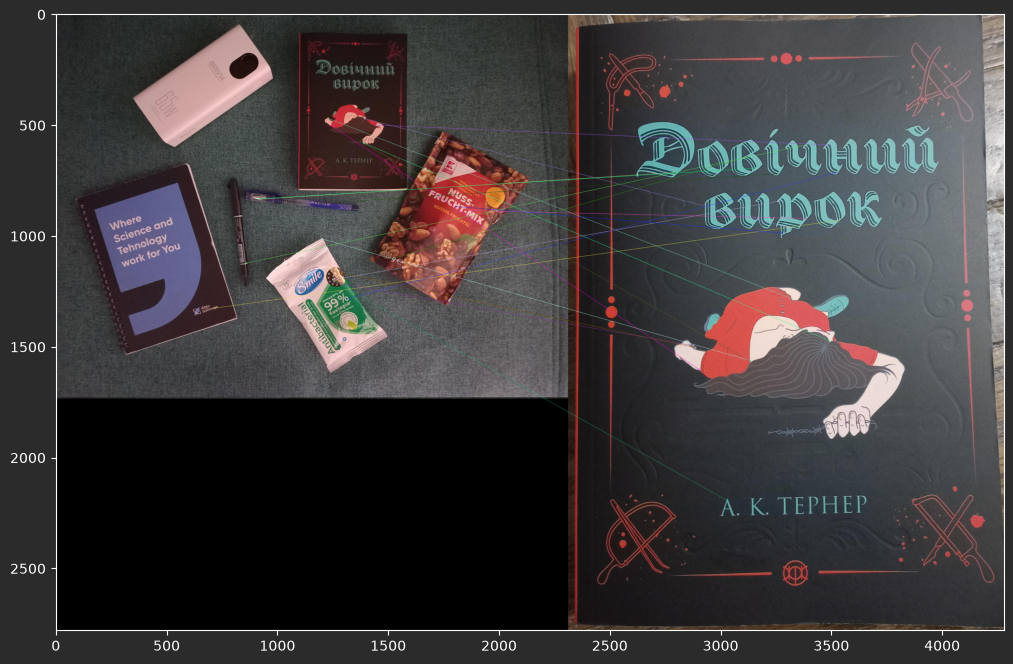

In [7]:
# Відображаємо топ-20 найкращих збігів
plt.figure(figsize=(16, 8))
img_matches = cv2.drawMatches(table_img, kp1, book_img, kp2, matches[:20], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(img_matches)

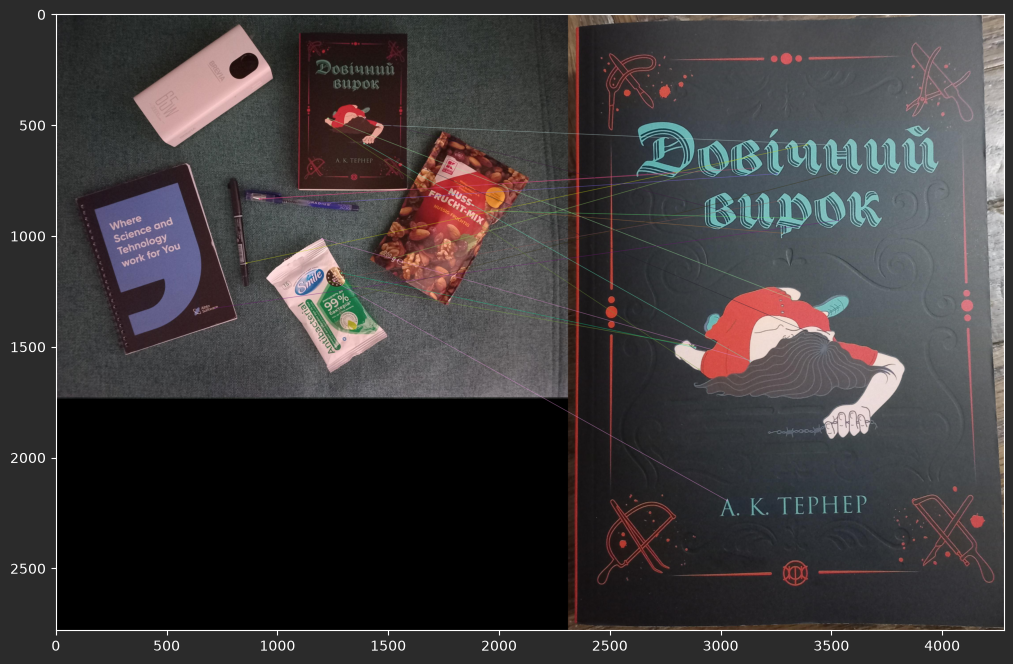

In [10]:
table_img = cv2.imread("input/table.jpeg", cv2.IMREAD_COLOR_RGB)
book_img = cv2.imread("input/book.jpeg", cv2.IMREAD_COLOR_RGB)

gray1 = cv2.cvtColor(table_img, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(book_img, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

matches = bf.match(des1, des2)


matches = sorted(matches, key=lambda x: x.distance)

plt.figure(figsize=(16, 8))
img_matches = cv2.drawMatches(table_img, kp1, book_img, kp2, matches[:20], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.imshow(img_matches)

## Гомографія зображень: приклад ортогоналізації підлоги

In [ ]:
image = cv2.imread("input/floor.jpeg", cv2.IMREAD_COLOR_RGB)

plt.imshow(image)

# top-left, top-right, bottom-right, bottom-left
x_coords = [450, 1350, 2010, 0]
y_coords = [650, 650, 1000, 1000]

plt.plot(x_coords, y_coords, 'ro', markersize=10)
plt.show()

In [ ]:
src_pts = np.array([[x_coords[0], y_coords[0]],
                    [x_coords[1], y_coords[1]],
                    [x_coords[2], y_coords[2]],
                    [x_coords[3], y_coords[3]]], dtype=np.float32)

dst_pts = np.float32([[0, 0], [1000, 0], [1000, 500], [0, 500]])

H, mask = cv2.findHomography(src_pts, dst_pts)
H

In [ ]:
warped = cv2.warpPerspective(image, H, (1000, 500))
plt.imshow(warped)

### Пошук об'єкта на фото

In [ ]:
table_img = cv2.imread("input/table2.jpeg", cv2.IMREAD_COLOR_RGB)
book_img = cv2.imread("input/book.jpeg", cv2.IMREAD_COLOR_RGB)

gray1 = cv2.cvtColor(table_img, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(book_img, cv2.COLOR_BGR2GRAY)

# 2. Ініціалізація детектора (SIFT)
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.knnMatch(des1, des2, k=2)


# Фільтрація згідно з тестом Лоу (Ratio Test)
good = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good.append(m)


# 4. Пошук гомографії
if len(good) > 10:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # 5. Трансформація
    h, w = table_img.shape[:2]
    result = cv2.warpPerspective(table_img, M, (book_img.shape[1], book_img.shape[0]))

    plot_images_in_row([book_img, result, table_img])